In [1]:
%pip install langchain langchain-openai langgraph azure-identity python-dotenv -q



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv
import os
load_dotenv()
print(os.environ.get("AZURE_AI_PROJECT_ENDPOINT"))
print(os.environ.get("AZURE_AI_MODEL_DEPLOYMENT_NAME"))

https://ai-agents-course-resource-pk.services.ai.azure.com/api/projects/ai-agents-course
Kimi-K2.6


In [12]:
!pip install langchain-azure-ai -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("langchain").setLevel(logging.ERROR)

import os
from dotenv import load_dotenv
load_dotenv("/workspaces/langchain-mastery/.env")

from langchain.agents import create_agent
from langchain_azure_ai.chat_models import AzureAIOpenAIApiChatModel
from langchain_core.tools import tool
from azure.identity import AzureCliCredential

# ── Tool ──────────────────────────────────────────────────────────────────
@tool
def get_destinations() -> list[str]:
    """Get a list of popular vacation destinations."""
    return [
        "Barcelona", "Paris", "Berlin", "Tokyo", "Sydney",
        "New York City", "Cairo", "Cape Town", "Rio de Janeiro", "Bali",
    ]

# ── LLM — correct way to connect to Azure AI Foundry ─────────────────────
llm = AzureAIOpenAIApiChatModel(
    project_endpoint=os.environ["AZURE_AI_PROJECT_ENDPOINT"],
    credential=AzureCliCredential(),
    model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
)

# ── Agent ─────────────────────────────────────────────────────────────────
agent = create_agent(
    model=llm,
    tools=[get_destinations],
    system_prompt=(
        "You are a helpful travel agent. Help users find their perfect vacation "
        "destination based on their preferences. Use the get_destinations tool "
        "to see available destinations."
    ),
)

# ── Run ───────────────────────────────────────────────────────────────────
response = agent.invoke({
    "messages": [{"role": "user", "content": "I'm looking for a warm beach destination. What do you recommend?"}]
})
print(response["messages"][-1].content)

[{'id': 'rs_05de33ff3a4388b6006a236245d10081908bddc365e350135e', 'summary': [{'text': "We have the list of destinations. The user wants a warm beach destination. From the list: Barcelona (Mediterranean, beaches), Sydney (beaches but currently June is winter there so not warm), Rio de Janeiro (beaches, warm), Bali (tropical island, beaches, warm). Cape Town also has beaches but June is winter and cold. Cairo is not really a beach destination.\n\nBest recommendations: Bali, Rio de Janeiro, Barcelona.\n\nWe should mention a few options, highlighting Bali and Rio as top warm beach picks, with Barcelona as a Mediterranean option (though sea might be cooler in June, the weather is warm). We need to be helpful and maybe ask if they have preferences between these, but provide a solid recommendation first.\n\nLet's craft a response recommending the best warm beach destinations from the list.", 'type': 'summary_text'}], 'type': 'reasoning', 'response_id': 'resp_05de33ff3a4388b6006a2362405d008190

In [3]:
# Clean output — just print the text response
for msg in response["messages"]:
    if hasattr(msg, "content") and isinstance(msg.content, list):
        for block in msg.content:
            if isinstance(block, dict) and block.get("type") == "text":
                print(block["text"])
    elif hasattr(msg, "content") and isinstance(msg.content, str):
        if msg.content:
            print(msg.content)

I'm looking for a warm beach destination. What do you recommend?
["Barcelona", "Paris", "Berlin", "Tokyo", "Sydney", "New York City", "Cairo", "Cape Town", "Rio de Janeiro", "Bali"]
Based on your preference for a warm beach destination, here are my top recommendations from our available list:

1. **Bali, Indonesia** – This is the ultimate tropical beach paradise with stunning coastlines, warm turquoise waters, and lush landscapes. Perfect for relaxation, surfing, and vibrant culture.

2. **Rio de Janeiro, Brazil** – Famous for iconic beaches like Copacabana and Ipanema, Rio offers golden sands, lively atmosphere, and beautiful mountain backdrops, all with warm weather year-round.

3. **Barcelona, Spain** – A great Mediterranean option with urban beaches like Barceloneta, warm weather, and the added bonus of incredible architecture and cuisine. Note that early June is pleasant, though the Mediterranean water is still warming up.

If I had to pick the absolute best for *warmth and beach 

# 🧠 Lesson 01 — Understanding What Just Happened

## What We Built

We built an **AI Agent** — a program that uses an LLM as its reasoning engine and can call
tools to accomplish a goal. Here is what the system looks like:

---

## What Happened Behind the Scenes — Step by Step

### Step 1 — You called `agent.invoke()`
You passed a user message:
> *"I'm looking for a warm beach destination. What do you recommend?"*

### Step 2 — LangGraph started the graph
`create_agent` internally builds a LangGraph `StateGraph`.
The state is a list of messages that grows with each step.

### Step 3 — LLM was called (model node)
The LLM (Kimi-K2.6 on Azure AI Foundry) received:
- The **system prompt** (your instructions as travel agent)
- The **user message**
- The **tool schema** (description of `get_destinations`)

The LLM decided: *"I need to call `get_destinations` to see what options are available."*

### Step 4 — Tool was called (tools node)
LangGraph detected a **tool call** in the LLM response and routed to the tools node.
Your Python function `get_destinations()` was executed and returned the list of cities.

### Step 5 — LLM was called again (model node)
The tool result was added to the message history.
The LLM now had:
- System prompt
- User message
- Tool result (list of destinations)

It then reasoned: *"Bali, Rio, Barcelona are warm in June. Sydney and Cape Town are in winter."*

### Step 6 — Final response
The LLM produced a final text response with no more tool calls.
LangGraph detected no tool calls → routed to END.
`agent.invoke()` returned the full message history.

---

## The ReAct Loop — Reason + Act

This pattern is called **ReAct** (Reasoning + Acting):

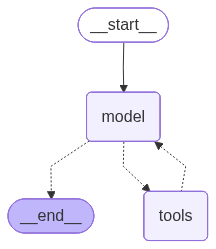

In [4]:
# Visualize the agent graph structure
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [8]:
# ✅ CORRECT — pass the message dict explicitly
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "I'm looking for a warm beach destination. What do you recommend?"}]},
    stream_mode="updates"
):
    print(chunk)

{'model': {'messages': [AIMessage(content=[{'id': 'rs_09896b4fb7a3c1f2006a23649adf888196afc6b87834844782', 'summary': [{'text': 'The user is looking for a warm beach destination recommendation. I should use the get_destinations tool to see what available destinations there are, and then I can help recommend something based on their preference for warm beach locations.', 'type': 'summary_text'}], 'type': 'reasoning', 'response_id': 'resp_09896b4fb7a3c1f2006a236499b4bc8196b660d15296ba093e'}, {'arguments': '{}', 'call_id': 'call_functions.get_destinations:0_agents', 'name': 'get_destinations', 'type': 'function_call', 'id': 'fc_09896b4fb7a3c1f2006a23649ae5988196a3633088b8fe4f2c', 'status': 'completed', 'response_id': 'resp_09896b4fb7a3c1f2006a236499b4bc8196b660d15296ba093e'}], additional_kwargs={}, response_metadata={'id': 'resp_09896b4fb7a3c1f2006a236499b4bc8196b660d15296ba093e', 'created_at': 1780704409.0, 'metadata': {}, 'model': 'Kimi-K2.6', 'object': 'response', 'service_tier': 'auto

In [9]:
def print_run_log(response):
    for i, msg in enumerate(response["messages"]):
        msg_type = type(msg).__name__
        print(f"\n[{i+1}] {msg_type}")
        content = msg.content
        if isinstance(content, str) and content:
            print(f"    {content[:300]}")
        elif isinstance(content, list):
            for block in content:
                if isinstance(block, dict):
                    btype = block.get("type", "")
                    if btype == "text":
                        print(f"    TEXT: {block['text'][:300]}")
                    elif btype == "tool_use":
                        print(f"    TOOL CALL: {block.get('name')} → {block.get('input')}")
                    elif btype == "tool_result":
                        print(f"    TOOL RESULT: {block.get('content')}")
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"    TOOL CALL: {tc['name']} → {tc['args']}")

# Use it like this always
print_run_log(response)


[1] HumanMessage
    I'm looking for a warm beach destination. What do you recommend?

[2] AIMessage
    TOOL CALL: get_destinations → {}

[3] ToolMessage
    ["Barcelona", "Paris", "Berlin", "Tokyo", "Sydney", "New York City", "Cairo", "Cape Town", "Rio de Janeiro", "Bali"]

[4] AIMessage
    TEXT: Based on your preference for a warm beach destination, here are my top recommendations from our available list:

1. **Bali, Indonesia** – This is the ultimate tropical beach paradise with stunning coastlines, warm turquoise waters, and lush landscapes. Perfect for relaxation, surfing, and vibrant cu


### The below ones might be specific

In [5]:
# Stream with full step-by-step visibility
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "I'm looking for a warm beach destination. What do you recommend?"}]},
    stream_mode="updates"
):
    print("─" * 50)
    for node_name, node_output in chunk.items():
        print(f"📍 Node: {node_name}")
        for msg in node_output.get("messages", []):
            if hasattr(msg, "content"):
                if isinstance(msg.content, list):
                    for block in msg.content:
                        if isinstance(block, dict):
                            if block.get("type") == "text":
                                print(f"   💬 Text: {block['text'][:200]}")
                            elif block.get("type") == "tool_use":
                                print(f"   🔧 Tool call: {block.get('name')}")
                            elif block.get("type") == "tool_result":
                                print(f"   ✅ Tool result: {block.get('content')}")
                else:
                    if msg.content:
                        print(f"   💬 {msg.content[:200]}")
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"   🔧 Tool call: {tc['name']} args={tc['args']}")

──────────────────────────────────────────────────
📍 Node: model
   🔧 Tool call: get_destinations args={}
──────────────────────────────────────────────────
📍 Node: tools
   💬 ["Barcelona", "Paris", "Berlin", "Tokyo", "Sydney", "New York City", "Cairo", "Cape Town", "Rio de Janeiro", "Bali"]
──────────────────────────────────────────────────
📍 Node: model
   💬 Text: Great news! From our available destinations, I have some excellent recommendations for a warm beach getaway. Since it's **June**, I'd steer you toward tropical or northern hemisphere spots where the w


In [6]:
# Full message history — shows every step
for i, msg in enumerate(response["messages"]):
    print(f"\n{'─'*50}")
    print(f"Message {i+1}: {type(msg).__name__}")
    if hasattr(msg, "content"):
        if isinstance(msg.content, list):
            for block in msg.content:
                if isinstance(block, dict):
                    print(f"  Type: {block.get('type')}")
                    if block.get("type") == "text":
                        print(f"  Text: {block['text'][:300]}")
        else:
            print(f"  Content: {str(msg.content)[:300]}")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  Tool calls: {[tc['name'] for tc in msg.tool_calls]}")


──────────────────────────────────────────────────
Message 1: HumanMessage
  Content: I'm looking for a warm beach destination. What do you recommend?

──────────────────────────────────────────────────
Message 2: AIMessage
  Type: reasoning
  Type: function_call
  Tool calls: ['get_destinations']

──────────────────────────────────────────────────
Message 3: ToolMessage
  Content: ["Barcelona", "Paris", "Berlin", "Tokyo", "Sydney", "New York City", "Cairo", "Cape Town", "Rio de Janeiro", "Bali"]

──────────────────────────────────────────────────
Message 4: AIMessage
  Type: reasoning
  Type: text
  Text: Based on your preference for a warm beach destination, here are my top recommendations from our available list:

1. **Bali, Indonesia** – This is the ultimate tropical beach paradise with stunning coastlines, warm turquoise waters, and lush landscapes. Perfect for relaxation, surfing, and vibrant cu


---

## ⚠️ Common Mistakes in This Lesson

### 1. Never name a variable `input`
```python
# ❌ WRONG — shadows Python built-in input() function
for chunk in agent.stream(input, ...):

# ✅ CORRECT — always use a named variable
user_message = {"messages": [{"role": "user", "content": "..."}]}
for chunk in agent.stream(user_message, ...):
```

### 2. Always run cells in order after kernel restart
After restarting the kernel all variables are lost.
Always run cells top to bottom:
1. pip install
2. load_dotenv + verify
3. imports + tool + llm + agent
4. invoke / stream

### 3. load_dotenv needs explicit path in Codespaces
```python
# ❌ May not find .env in Codespaces
load_dotenv()

# ✅ Always use explicit path
load_dotenv("/workspaces/<your-repo>/.env")
```

### 4. Wrong LLM class for non-OpenAI models
```python
# ❌ AzureChatOpenAI → 401 error with Kimi, Mistral, Llama
from langchain_openai import AzureChatOpenAI

# ✅ AzureAIOpenAIApiChatModel → works with any Foundry model
from langchain_azure_ai.chat_models import AzureAIOpenAIApiChatModel
```

---

## 📋 Lesson 01 — Cell Summary

| Cell | What it does |
|---|---|
| pip install | Installs all required packages |
| load_dotenv | Loads Azure endpoint and model name from .env |
| @tool | Defines a Python function the LLM can call |
| AzureAIOpenAIApiChatModel | Connects to Azure AI Foundry |
| create_agent | Builds a LangGraph state machine internally |
| agent.invoke() | Runs the full ReAct loop, returns final response |
| agent.stream() | Same but yields chunks as they are generated |
| draw_mermaid_png() | Visualizes the graph nodes and edges |
| print_run_log() | Prints full message trace for debugging |

---

## ✅ Lesson 01 Complete

You now understand:
- What an AI agent is and how it differs from a simple LLM call
- How LangChain, LangGraph, and Azure AI Foundry fit together
- How the ReAct loop works — Thought → Tool Call → Observation → Answer
- How to define tools, create agents, invoke and stream responses
- How to visualize and debug agent execution

**Next: Lesson 02 — Multi-step Reasoning and Powerful Tools**